In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import seaborn as sns
from sklearn import linear_model 

In [3]:
df = pd.read_csv('CH06PR15.txt', header=None, sep=r'\s+', names=['Age', 'Severity', 'Anxiety', 'Satisfaction'])

X = df[['Age', 'Severity', 'Anxiety']]
y = df['Satisfaction']

n = X.shape[0]
p = X.shape[1]

alpha = 0.05

# A

In [4]:
X_const = np.column_stack((np.ones(n), X))

beta_manual = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ y
y_pred_manual = X_const @ beta_manual

SST = np.sum((y - y.mean())**2)
SSE = np.sum((y - y_pred_manual)**2)
SSM = SST - SSE

R_squared_manual = SSM / SST

print("--- WYNIKI RĘCZNE ---")
print(f"Intercept: {beta_manual[0]:.4f}")
features = ['Age', 'Severity', 'Anxiety']
for feature, coef in zip(features, beta_manual[1:]):
    print(f"{feature}: {coef:.4f}")
print(f"R^2: {R_squared_manual:.4f}")
print("\n")


--- WYNIKI RĘCZNE ---
Intercept: 1.0532
Age: -0.0059
Severity: 0.0019
Anxiety: 0.0301
R^2: 0.5415




In [5]:
model_sm = sm.OLS(y, X_const).fit()

print("--- WYNIKI BIBLIOTECZNE (STATSMODELS) ---")
print(f"Intercept: {model_sm.params.iloc[0]:.4f}")
for feature, coef in zip(X.columns, model_sm.params.iloc[1:]):
    print(f"{feature}: {coef:.4f}")
print(f"R^2: {model_sm.rsquared:.4f}")

--- WYNIKI BIBLIOTECZNE (STATSMODELS) ---
Intercept: 1.0532
Age: -0.0059
Severity: 0.0019
Anxiety: 0.0301
R^2: 0.5415



# B
$H_0: \beta_1 = \beta_2 = \beta_3 = 0$

$H_1$: Przynajmniej jedno $\beta_k \neq 0$

In [6]:
SSE_full = np.sum((y - y_pred_manual)**2)

df_full = X.shape[0] - X_const.shape[1] 

SSE_reduced = np.sum((y - y.mean())**2)

df_reduced = X.shape[0] - 1


numerator = (SSE_reduced - SSE_full) / (df_reduced - df_full)

denominator = SSE_full / df_full

F_stat = numerator / denominator

p_value = 1 - stats.f.cdf(F_stat, df_reduced - df_full, df_full)

print("--- WYNIK RĘCZNY ---")
print(f"Statystyka F:      {F_stat:.4f}")
print(f"Wartość p:         {p_value:.4e}")


print("\n--- WYNIK BIBLIOTECZNY ---")
print(f"Bibl. F-stat:      {model_sm.fvalue:.4f}")
print(f"Bibl. p-value:     {model_sm.f_pvalue:.4e}")

--- WYNIK RĘCZNY ---
Statystyka F:      16.5376
Wartość p:         3.0431e-07

--- WYNIK BIBLIOTECZNY ---
Bibl. F-stat:      16.5376
Bibl. p-value:     3.0431e-07


In [7]:
print("\n--- WNIOSKI Z TESTU F ---")
print(f"Poziom istotności alpha: {alpha}")
print(f"Hipoteza H0: Wszystkie zmienne (Age, Severity, Anxiety) mają współczynnik 0.")
print(f"Hipoteza H1: Przynajmniej jedna zmienna wpływa na wynik.")

if p_value < alpha:
    print("DECYZJA: ODRZUCAMY H0.")
    print("Wniosek: Model jest istotny statystycznie. Przynajmniej jedna zmienna objaśniająca wpływa na Satysfakcję.")
else:
    print("DECYZJA: BRAK PODSTAW DO ODRZUCENIA H0.")
    print("Wniosek: Model nie jest istotny statystycznie.")


--- WNIOSKI Z TESTU F ---
Poziom istotności alpha: 0.05
Hipoteza H0: Wszystkie zmienne (Age, Severity, Anxiety) mają współczynnik 0.
Hipoteza H1: Przynajmniej jedna zmienna wpływa na wynik.
DECYZJA: ODRZUCAMY H0.
Wniosek: Model jest istotny statystycznie. Przynajmniej jedna zmienna objaśniająca wpływa na Satysfakcję.


# C

In [8]:
df_error = n - p - 1 
t_critical = stats.t.ppf(1 - alpha/2, df_error) 

print(f"Stopnie swobody dla błędu (df): {df_error}")
print(f"Wartość krytyczna t (dla 95%): {t_critical:.4f}\n")

# Obliczenie SSE (na wypadek gdyby zmienna nie istniala)
y_pred_manual = X_const @ beta_manual
SSE = np.sum((y - y_pred_manual)**2)
MSE = SSE / df_error

invXTX = np.linalg.inv(X_const.T @ X_const)
cov_beta = MSE * invXTX

se_beta = np.sqrt(np.diag(cov_beta))

print("--- WYNIKI RĘCZNE ---")
variables = ['Intercept'] + list(X.columns) 

for i, var_name in enumerate(variables):
    if i == 0: continue 
        
    b = beta_manual[i]
    se = se_beta[i]
    
    t_stat = b / se
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df_error))
    
    ci_lower = b - t_critical * se
    ci_upper = b + t_critical * se
    
    print(f"Zmienna: {var_name.upper()}")
    print(f"  H0: beta_{var_name} = 0  vs  H1: beta_{var_name} != 0")
    print(f"  Współczynnik: {b:.4f}")
    print(f"  Błąd std (SE): {se:.4f}")
    print(f"  Statystyka t: {t_stat:.4f} (df={df_error})")
    print(f"  Wartość p:    {p_val:.4e}")
    print(f"  95% CI:       [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    if p_val < alpha:
        print("  Konkluzja: ODRZUCAMY H0 (Istotna statystycznie)")
    else:
        print("  Konkluzja: BRAK PODSTAW DO ODRZUCENIA H0 (Nieistotna)")
    print("-" * 40)


print("\n--- WYNIKI BIBLIOTECZNE ---")

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

conf_intervals = model_sm.conf_int(alpha=alpha)
p_values = model_sm.pvalues
t_values = model_sm.tvalues

for var_name in X.columns:
    p_val = p_values[var_name]
    t_val = t_values[var_name]
    
    ci_low = conf_intervals.loc[var_name, 0]
    ci_high = conf_intervals.loc[var_name, 1]
    
    print(f"Zmienna: {var_name}")
    print(f"  p-value: {p_val:.4e} | t-stat: {t_val:.4f}")
    print(f"  CI bibl: [{ci_low:.4f}, {ci_high:.4f}]")

Stopnie swobody dla błędu (df): 42
Wartość krytyczna t (dla 95%): 2.0181

--- WYNIKI RĘCZNE ---
Zmienna: AGE
  H0: beta_Age = 0  vs  H1: beta_Age != 0
  Współczynnik: -0.0059
  Błąd std (SE): 0.0031
  Statystyka t: -1.8973 (df=42)
  Wartość p:    6.4678e-02
  95% CI:       [-0.0121, 0.0004]
  Konkluzja: BRAK PODSTAW DO ODRZUCENIA H0 (Nieistotna)
----------------------------------------
Zmienna: SEVERITY
  H0: beta_Severity = 0  vs  H1: beta_Severity != 0
  Współczynnik: 0.0019
  Błąd std (SE): 0.0058
  Statystyka t: 0.3332 (df=42)
  Wartość p:    7.4065e-01
  95% CI:       [-0.0097, 0.0136]
  Konkluzja: BRAK PODSTAW DO ODRZUCENIA H0 (Nieistotna)
----------------------------------------
Zmienna: ANXIETY
  H0: beta_Anxiety = 0  vs  H1: beta_Anxiety != 0
  Współczynnik: 0.0301
  Błąd std (SE): 0.0093
  Statystyka t: 3.2569 (df=42)
  Wartość p:    2.2323e-03
  95% CI:       [0.0115, 0.0488]
  Konkluzja: ODRZUCAMY H0 (Istotna statystycznie)
----------------------------------------

--- WYNI

# D

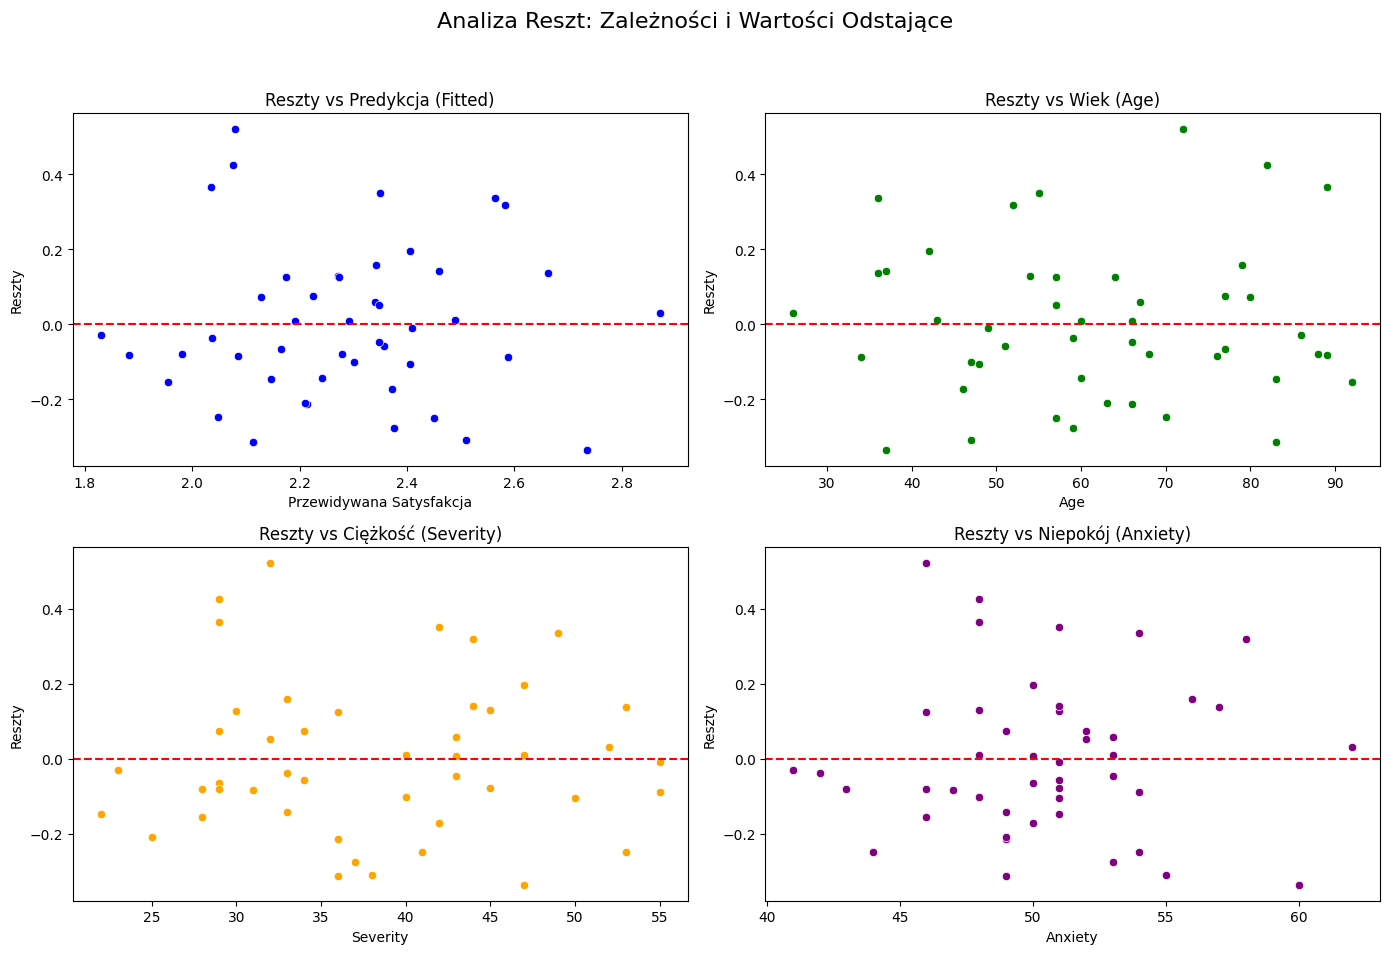

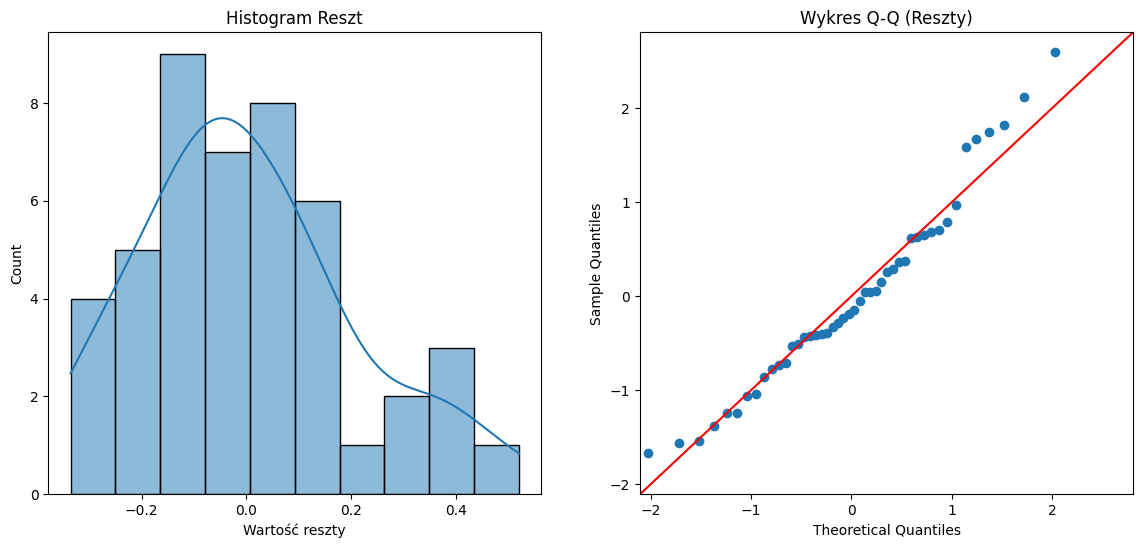

--- TEST SHAPIRO-WILKA (Normalność reszt) ---
H0: Reszty mają rozkład normalny.
H1: Reszty nie mają rozkładu normalnego.
Statystyka W: 0.9629
Wartość p:    0.1481
DECYZJA: BRAK PODSTAW DO ODRZUCENIA H0.
Wniosek: Można przyjąć, że reszty mają rozkład normalny.


In [9]:
residuals = model_sm.resid
fitted_values = model_sm.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analiza Reszt: Zależności i Wartości Odstające', fontsize=16)

# 1 Reszty vs Przewidywana Satysfakcja (Fitted values)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0, 0], color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Reszty vs Predykcja (Fitted)')
axes[0, 0].set_xlabel('Przewidywana Satysfakcja')
axes[0, 0].set_ylabel('Reszty')

# 2. Reszty vs Wiek (Age)
sns.scatterplot(x=df['Age'], y=residuals, ax=axes[0, 1], color='green')
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_title('Reszty vs Wiek (Age)')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Reszty')

# 3. Reszty vs Ciężkość (Severity)
sns.scatterplot(x=df['Severity'], y=residuals, ax=axes[1, 0], color='orange')
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Reszty vs Ciężkość (Severity)')
axes[1, 0].set_xlabel('Severity')
axes[1, 0].set_ylabel('Reszty')

# 4. Reszty vs Niepokój (Anxiety)
sns.scatterplot(x=df['Anxiety'], y=residuals, ax=axes[1, 1], color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Reszty vs Niepokój (Anxiety)')
axes[1, 1].set_xlabel('Anxiety')
axes[1, 1].set_ylabel('Reszty')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 5. Wizualizacja: Histogram i QQ-Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
sns.histplot(residuals, kde=True, ax=ax[0], bins=10)
ax[0].set_title('Histogram Reszt')
ax[0].set_xlabel('Wartość reszty')

# QQ-Plot
sm.qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Wykres Q-Q (Reszty)')

plt.show()

# B. Test Statystyczny: Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
shapiro_stat = shapiro_test.statistic
shapiro_p = shapiro_test.pvalue

print("--- TEST SHAPIRO-WILKA (Normalność reszt) ---")
print(f"H0: Reszty mają rozkład normalny.")
print(f"H1: Reszty nie mają rozkładu normalnego.")
print(f"Statystyka W: {shapiro_stat:.4f}")
print(f"Wartość p:    {shapiro_p:.4f}")

if shapiro_p > alpha:
    print("DECYZJA: BRAK PODSTAW DO ODRZUCENIA H0.")
    print("Wniosek: Można przyjąć, że reszty mają rozkład normalny.")
else:
    print("DECYZJA: ODRZUCAMY H0.")
    print("Wniosek: Reszty NIE mają rozkładu normalnego (należy uważać z interpretacją testów t i F).")

# E

Model Pełny: Y = b0 + b1*Age + b2*Severity + b3*Anxiety

Model Zredukowany: Y = b0 + b1*Age

In [10]:
beta_full = np.linalg.inv(X_const.T @ X_const) @ X_const.T @ y
y_pred_full = X_const @ beta_full
SSE_full = np.sum((y - y_pred_full)**2)
df_full = X.shape[0] - X_const.shape[1] 


X_reduced_data = df[['Age']] 
X_reduced_const = np.column_stack((np.ones(n), X_reduced_data))

beta_reduced = np.linalg.inv(X_reduced_const.T @ X_reduced_const) @ X_reduced_const.T @ y
y_pred_reduced = X_reduced_const @ beta_reduced
SSE_reduced = np.sum((y - y_pred_reduced)**2)
df_reduced = X.shape[0] - X_reduced_const.shape[1]

# Statystyka F

numerator = (SSE_reduced - SSE_full) / (df_reduced - df_full)
denominator = SSE_full / df_full

F_stat_partial = numerator / denominator

# df1 = różnica liczby parametrów (tutaj 2: Severity i Anxiety), df2 = df błędu modelu pełnego
p_value_partial = 1 - stats.f.cdf(F_stat_partial, df_reduced - df_full, df_full)

print("--- WYNIKI RĘCZNE ---")
print(f"SSE Reduced (tylko Age): {SSE_reduced:.4f} (df={df_reduced})")
print(f"SSE Full (3 zmienne):    {SSE_full:.4f} (df={df_full})")
print(f"Statystyka F:            {F_stat_partial:.4f}")
print(f"Wartość p:               {p_value_partial:.4e}")


print("\n--- WYNIKI BIBLIOTECZNE ---")

# Musimy zbudować obiekt modelu zredukowanego w statsmodels
X_red_sm = sm.add_constant(df[['Age']])
model_reduced_sm = sm.OLS(y, X_red_sm).fit()

f_test_result = model_sm.compare_f_test(model_reduced_sm)
print(f"Statystyka F:            {f_test_result[0]:.4f}")
print(f"Wartość p:               {f_test_result[1]:.4e}")


print("\n--- KONKLUZJA ---")
print(f"Hipoteza zerowa H0: Współczynniki przy Severity i Anxiety są równe 0.")
print(f"Hipoteza alternatywna H1: Dodanie tych zmiennych istotnie poprawia model.")

if p_value_partial < alpha:
    print("DECYZJA: ODRZUCAMY H0.")
    print("Wniosek: Model z 3 zmiennymi jest istotnie lepszy niż model z samym Wiekiem.")
    print("         Zmienne 'Severity' i 'Anxiety' niosą istotną informację.")
else:
    print("DECYZJA: BRAK PODSTAW DO ODRZUCENIA H0.")
    print("Wniosek: Dodanie zmiennych 'Severity' i 'Anxiety' nie poprawia istotnie modelu.")

--- WYNIKI RĘCZNE ---
SSE Reduced (tylko Age): 2.3568 (df=44)
SSE Full (3 zmienne):    1.8486 (df=42)
Statystyka F:            5.7739
Wartość p:               6.0905e-03

--- WYNIKI BIBLIOTECZNE ---
Statystyka F:            5.7739
Wartość p:               6.0905e-03

--- KONKLUZJA ---
Hipoteza zerowa H0: Współczynniki przy Severity i Anxiety są równe 0.
Hipoteza alternatywna H1: Dodanie tych zmiennych istotnie poprawia model.
DECYZJA: ODRZUCAMY H0.
Wniosek: Model z 3 zmiennymi jest istotnie lepszy niż model z samym Wiekiem.
         Zmienne 'Severity' i 'Anxiety' niosą istotną informację.


In [11]:
def save_simple_tex(df, filename, caption, label):
    df_out = df.copy()
    
    def fmt(x):
        if x is None or (isinstance(x, float) and np.isnan(x)): 
            return "---"
        if isinstance(x, (float, np.floating)):
            if abs(x) < 1e-12: return "0.0000"
            if abs(x) < 0.001 or abs(x) > 1e4: return "{:.2e}".format(x)
            return "{:.4f}".format(x)
        return x
        
    df_out = df_out.apply(lambda col: col.map(fmt))
    
    new_cols = [str(c).replace("%", "\\%").replace("_", " ") for c in df_out.columns]
    df_out.columns = new_cols

    with open(filename, 'w') as f:
        latex_str = df_out.to_latex(
            index=False, 
            caption=caption, 
            label=label,
            position="H", 
            column_format="l" + "c"*len(df_out.columns), 
            escape=False
        )
        f.write(latex_str)
    print(f"[OK] Zapisano: {filename}")

conf_int = model_sm.conf_int()
df_coeffs = pd.DataFrame({
    'Zmienna': model_sm.params.index,
    'Współczynnik': model_sm.params.values,
    'Błąd Std': model_sm.bse.values,
    'Statystyka t': model_sm.tvalues.values,
    'p-value': model_sm.pvalues.values,
    '95% CI Dolny': conf_int[0].values,
    '95% CI Górny': conf_int[1].values
})

df_model_fit = pd.DataFrame([{
    'R-kwadrat': model_sm.rsquared,
    'Adj. R-kwadrat': model_sm.rsquared_adj,
    'Statystyka F': model_sm.fvalue,
    'p-value (F)': model_sm.f_pvalue,
    'df Model': model_sm.df_model,
    'df Reszty': model_sm.df_resid
}])

df_shapiro = pd.DataFrame([{
    'Test': 'Shapiro-Wilk',
    'Statystyka W': shapiro_stat,
    'p-value': shapiro_p,
    'Decyzja (alpha=0.05)': 'Normality' if shapiro_p > 0.05 else 'Not Normal'
}])

df_compare = pd.DataFrame([{
    'SSE Full': SSE_full,
    'SSE Reduced (Age only)': SSE_reduced,
    'Statystyka F': F_stat_partial,
    'p-value': p_value_partial,
    'Decyzja': 'Odrzucić H0' if p_value_partial < 0.05 else 'Przyjąć H0'
}])


save_simple_tex(df_coeffs, "tab_zad1_coeffs.tex", 
                "Estymatory, testy istotności i przedziały ufności (Zadanie 1a, 1c)", "tab:zad1_coeffs")

save_simple_tex(df_model_fit, "tab_zad1_fit.tex", 
                "Ocena dopasowania modelu i ogólny test F (Zadanie 1b)", "tab:zad1_fit")

save_simple_tex(df_shapiro, "tab_zad1_shapiro.tex", 
                "Test normalności reszt Shapiro-Wilka (Zadanie 1d)", "tab:zad1_shapiro")

save_simple_tex(df_compare, "tab_zad1_compare.tex", 
                "Częściowy test F: Model pełny vs zredukowany (Zadanie 1e)", "tab:zad1_compare")

[OK] Zapisano: tab_zad1_coeffs.tex
[OK] Zapisano: tab_zad1_fit.tex
[OK] Zapisano: tab_zad1_shapiro.tex
[OK] Zapisano: tab_zad1_compare.tex


[OK] Zapisano wykres: wykres_zad1_reszty.png


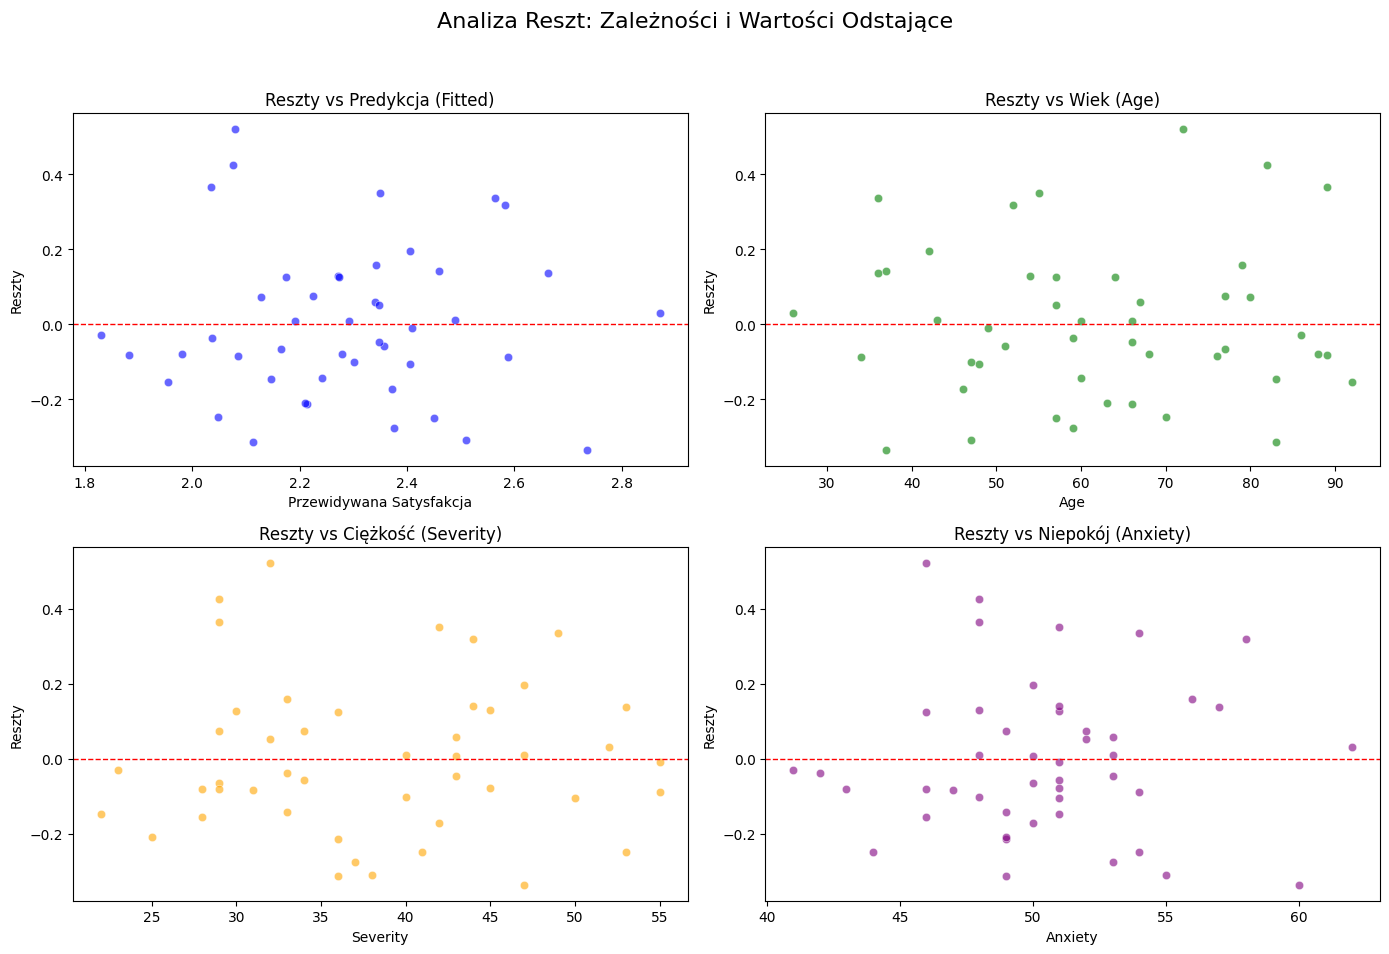

[OK] Zapisano wykres: wykres_zad1_normalnosc.png


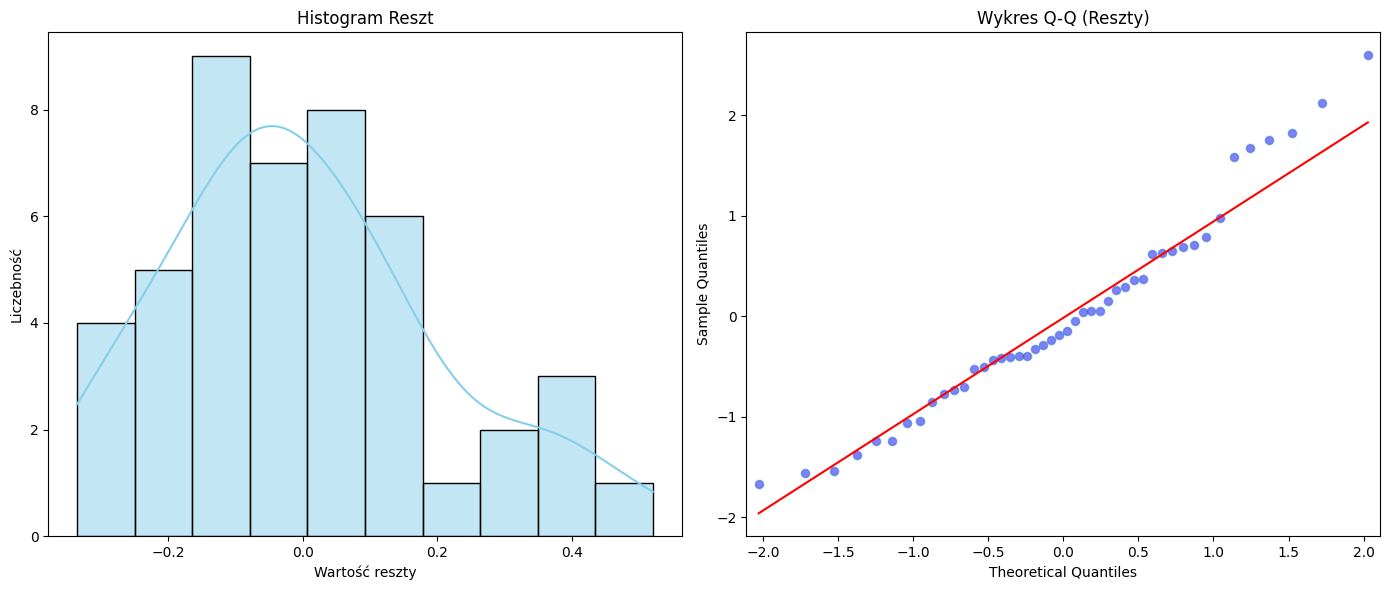

In [ ]:
residuals = model_sm.resid
fitted_values = model_sm.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analiza Reszt: Zależności i Wartości Odstające', fontsize=16)

sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0, 0], color='blue', alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Reszty vs Predykcja (Fitted)')
axes[0, 0].set_xlabel('Przewidywana Satysfakcja')
axes[0, 0].set_ylabel('Reszty')

sns.scatterplot(x=df['Age'], y=residuals, ax=axes[0, 1], color='green', alpha=0.6)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Reszty vs Wiek (Age)')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Reszty')

sns.scatterplot(x=df['Severity'], y=residuals, ax=axes[1, 0], color='orange', alpha=0.6)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Reszty vs Ciężkość (Severity)')
axes[1, 0].set_xlabel('Severity')
axes[1, 0].set_ylabel('Reszty')

sns.scatterplot(x=df['Anxiety'], y=residuals, ax=axes[1, 1], color='purple', alpha=0.6)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('Reszty vs Niepokój (Anxiety)')
axes[1, 1].set_xlabel('Anxiety')
axes[1, 1].set_ylabel('Reszty')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

filename1 = "wykres_zad1_reszty.png"
plt.savefig(filename1, dpi=300, bbox_inches='tight')
print(f"[OK] Zapisano wykres: {filename1}")
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(residuals, kde=True, ax=ax[0], bins=10, color='skyblue', edgecolor='black')
ax[0].set_title('Histogram Reszt')
ax[0].set_xlabel('Wartość reszty')
ax[0].set_ylabel('Liczebność')

sm.qqplot(residuals, line='q', fit=True, ax=ax[1], markerfacecolor='blue', alpha=0.5)
ax[1].set_title('Wykres Q-Q (Reszty)')

plt.tight_layout()

filename2 = "wykres_zad1_normalnosc.png"
plt.savefig(filename2, dpi=300, bbox_inches='tight')
print(f"[OK] Zapisano wykres: {filename2}")
plt.show()